# EA722 – Laboratório de Controle e Servomecanismo

## Experiência 2: Introdução à Realimentação

Universidade Estadual de Campinas – UNICAMP <br>
Faculdade de Engenharia Elétrica e de Computação – FEEC <br>

**Professor:** Caíque Santos Lima <br>
**Grupo / Bancada:** T1, T2, R1, R2 ou E <br>
**Turma:** V <br>
**Aluno(a):** Mariana Leister Gonçalves, **RA:** 233115 <br>
**Aluno(a):** , **RA:** ?????? <br>
**Aluno(a):** , **RA:** ?????? <br>

## Bibliotecas

In [4]:
%pip install control numpy pandas plotly matplotlib

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import pandas as pd
import control as ctrl
import plotly.graph_objects as go
import matplotlib.pyplot as plt

## (1) Controle em malha aberta × controle proporcional ao erro

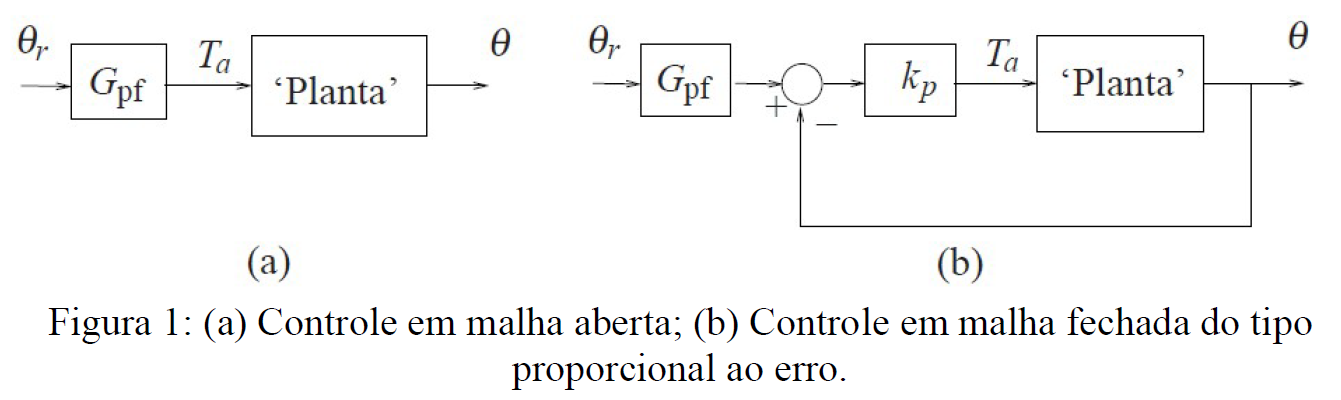

##### (a) Função de transferência de malha aberta

Funções de transferência:
Planta: $G(s) = \frac{1}{s^2 + 2s + 5}$
    
Malha aberta: $G_{MA} = \frac{G_{pf}}{s^2 + 2s + 5}$
    
Malha fechada: $G_{MF} = \frac{G_{pf}k_p}{s^2 + 2s + 5 + k_p}$

Na configuração em malha aberta, o sistema é composto por um ganho de pré-filtro $G_{pf}$ em série com a planta $G(s) = \frac{1}{s^2 + 2s + 5}$.
Como não há realimentação, a função de transferência do sistema em malha aberta é dada pelo produto entre o pré-filtro e a planta, isto é, $G_{MA}(s) = G_{pf}\,G(s) = \frac{G_{pf}}{s^2 + 2s + 5}$.

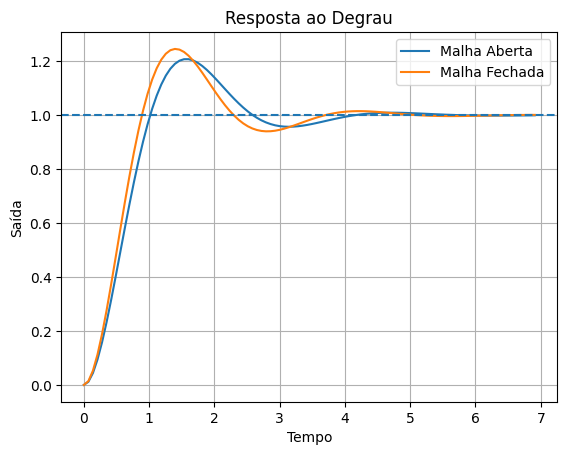

Ganho DC da planta: 0.2
G_pf (malha aberta): 5.0
G_pf (malha fechada): 6.0
Funções de transferência:
Malha aberta: G_MA = Gpf / (s^2 + 2s + 5)
Malha fechada: G_MF = (Gpf*kp) / (s^2 + 2s + 5 + kp)


In [ ]:
s = ctrl.TransferFunction.s
G = 1 / (s**2 + 2*s + 5) # Função de transferência da planta

# Malha aberta
Gpf_open = 1            # Valor inicial do ganho
G_MA = Gpf_open * G     # Função de tranferência em malha aberta

# Malha fechada
kp = 1  # Ganho do controlador
G_closed_loop = ctrl.feedback(kp * G, 1) # Malha fechada com realimentação unitária
# G_MF = (kp*G) / (1 + kp*G)


# Pré-Filtro
# Como desejamos erro nulo ao degrau, o ganho DC total deve ser 1

# Em malha aberta
dc_gain_open = ctrl.dcgain(G)
Gpf_open = 1 / dc_gain_open     # G_pf = 1 / G(0)

# GANHO DE MALHA ABERTA
G_MA = Gpf_open * G     # Atualiza malha aberta com o valor correto

# Em malha fechada
dc_gain_closed = ctrl.dcgain(G_closed_loop)
Gpf_closed = 1 / dc_gain_closed

# GANHO DE MALHA FECHADA
G_MF = Gpf_closed * G_closed_loop

# Resposta ao degrau (domínio do tempo)
t1, y1 = ctrl.step_response(G_MA)
t2, y2 = ctrl.step_response(G_MF)

#############

plt.plot(t1, y1, label="Malha Aberta")
plt.plot(t2, y2, label="Malha Fechada")
plt.axhline(1, linestyle='--')  # referência do degrau
plt.xlabel("Tempo")
plt.ylabel("Saída")
plt.title("Resposta ao Degrau")
plt.legend()
plt.grid()
plt.show()


In [7]:
# @title Gráficos (c)

# =========================
# Parâmetros
# =========================

deltas = np.arange(1, 4.5, 0.5)
t = np.linspace(0, 10, 1000)

# =========================
# (c) MALHA ABERTA
# =========================

Gpf_open = 5  # obtido no item (b)

fig_open = go.Figure()
erro_open = []

for Delta in deltas:

    # Planta perturbada
    num = [1]
    den = [1, 2, 5 - Delta]
    Gpert = ctrl.TransferFunction(num, den)

    # Sistema em malha aberta
    G_open = Gpf_open * Gpert

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_open, t)

    fig_open.add_trace(go.Scatter(
        x=t_out,
        y=y,
        mode='lines',
        name=f'Δ = {Delta}'
    ))

    # Erro de regime permanente analítico
    ess = -Delta / (5 - Delta)
    erro_open.append(ess)

fig_open.update_layout(
    title=dict(text='Resposta ao Degrau <br> Malha Aberta',
               x=0.5),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída θ(t)',
    width=600,
    height=400,
)

fig_open.show()

# =========================
# Erro vs. Delta - Malha Aberta
# =========================

fig_erro_open = go.Figure()

fig_erro_open.add_trace(go.Scatter(
    x=deltas,
    y=erro_open,
    mode='lines+markers'
))

fig_erro_open.update_layout(
    title=dict(text='Erro de Regime vs. Δ <br> Malha Aberta',
               x=0.5),
    xaxis_title='Δ',
    yaxis_title='Erro de Regime',
    width=600,
    height=400,
)

fig_erro_open.show()

ValueError: Mime type rendering requires nbformat>=4.2.0 but it is not installed

In [ ]:
# @title Gráficos (e)

# =========================
# Parâmetros
# =========================

kp_values = np.arange(3, 18, 3)  # 3,6,9,12,15
t = np.linspace(0, 10, 1000)

# =========================
# Resposta ao Degrau - Δ = 0
# =========================

fig_nominal = go.Figure()
erro_nominal = []

for kp in kp_values:

    Delta = 0

    # Pré-filtro calculado com planta nominal
    Gpf = (5 + kp) / kp

    # Planta
    num = [1]
    den = [1, 2, 5 - Delta]
    G = ctrl.TransferFunction(num, den)

    # Malha fechada
    G_forward = kp * G
    G_closed = ctrl.feedback(G_forward, 1)

    # Aplicando pré-filtro
    G_total = Gpf * G_closed

    # Resposta ao degrau
    t_out, y = ctrl.step_response(G_total, t)

    fig_nominal.add_trace(go.Scatter(
        x=t_out,
        y=y,
        mode='lines',
        name=f'kp = {kp}'
    ))

    # Erro analítico
    ess = -Delta / (kp + 5 - Delta)
    erro_nominal.append(ess)

fig_nominal.update_layout(
    title=dict(text='Resposta ao Degrau <br> Δ = 0 (Planta Nominal)',
               x=0.5),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída θ(t)',
    width=600,
    height=400,
)

fig_nominal.show()


# =========================
# Resposta ao Degrau - Δ = 2
# =========================

...


# =========================
# Erro vs. kp
# =========================

fig_erro = go.Figure()

fig_erro.add_trace(go.Scatter(
    x=kp_values,
    y=erro_nominal,
    mode='lines+markers',
    name='Δ = 0'
))

fig_erro.add_trace(go.Scatter(
    x=kp_values,
    y=erro_pert,
    mode='lines+markers',
    name='Δ = 2'
))

fig_erro.update_layout(
    title=dict(text='Erro de Regime vs. kp',
               x=0.5),
    xaxis_title='kp',
    yaxis_title='Erro de Regime',
    width=600,
    height=400,
)

fig_erro.show()

## (2) Controladores PID: regras de Ziegler–Nichols

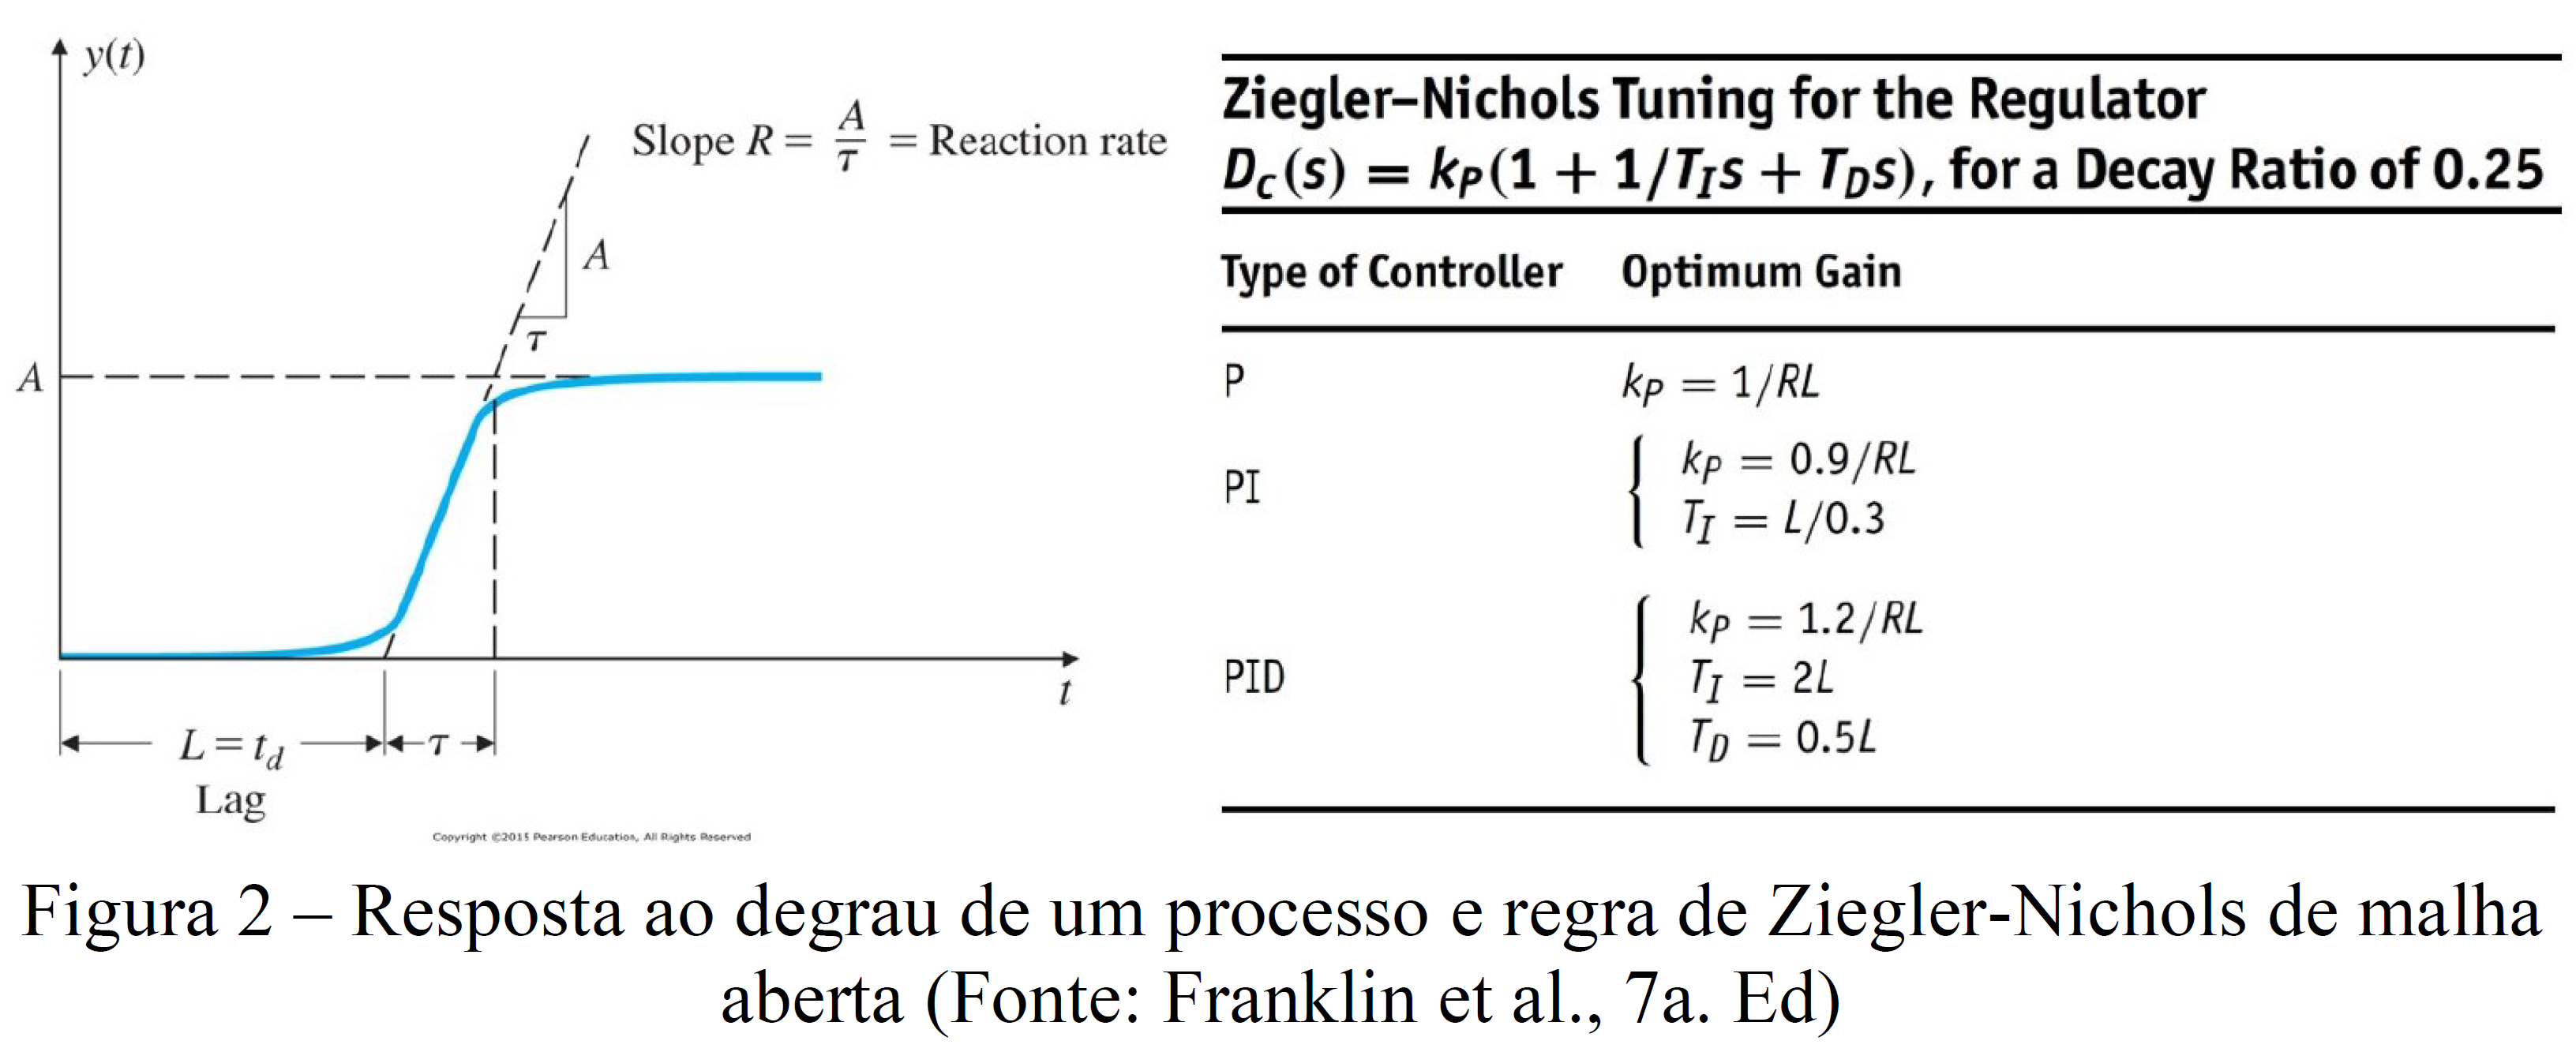

In [ ]:
# @title Gráfico (a)

# =========================
# Tempo de simulação
# =========================

t = np.linspace(0, 20, 1000)

# =========================
# Planta
# =========================

num = [10]
den = np.polymul([1,1], np.polymul([1,2], np.polymul([1,3],[1,4])))
G = ctrl.TransferFunction(num, den)

# =========================
# Parâmetros Ziegler-Nichols
# =========================

Kp_P =

Kp_PI =
Ti_PI =

Kp_PID =
Ti_PID =
Td_PID =

# =========================
# Controladores
# =========================

Cp = Kp_P

Cpi = Kp_PI * ctrl.TransferFunction([Ti_PI,1],[Ti_PI,0])

Cpid = Kp_PID * ctrl.TransferFunction(
    [Ti_PID*Td_PID, Ti_PID, 1],
    [Ti_PID, 0]
)

# =========================
# Sistemas em malha fechada
# =========================

Tp = ctrl.feedback(Cp*G,1)
Tpi = ctrl.feedback(Cpi*G,1)
Tpid = ctrl.feedback(Cpid*G,1)

# =========================
# Respostas ao degrau
# =========================

t_p, y_p = ctrl.step_response(Tp, t)
t_pi, y_pi = ctrl.step_response(Tpi, t)
t_pid, y_pid = ctrl.step_response(Tpid, t)

# =========================
# Plot
# =========================

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=t_p,
    y=y_p,
    mode='lines',
    name='P'
))

fig.add_trace(go.Scatter(
    x=t_pi,
    y=y_pi,
    mode='lines',
    name='PI'
))

fig.add_trace(go.Scatter(
    x=t_pid,
    y=y_pid,
    mode='lines',
    name='PID'
))

fig.update_layout(
    title=dict(
        text='Resposta ao Degrau <br> Controladores Ziegler-Nichols (Malha Aberta)',
        x=0.5
    ),
    xaxis_title='Tempo (s)',
    yaxis_title='Saída y(t)',
    width=700,
    height=450,
)

fig.show()

In [ ]:
# @title Gráfico de suporte (b)

ctrl.nyquist_plot(G)
plt.show()

Ku, pm, wg, wp = ctrl.margin(G)

Pu = 2 * np.pi / wg

print(Ku)
print(Pu)